# EDA Técnico: Justificación de Predictores y Priors - Tomás
Este cuaderno contiene el Análisis Exploratorio de Datos enfocado en **evidenciar por qué seleccionamos ciertas variables** para nuestro modelo Bayesiano y cómo se relacionan directamente con la **victoria**.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.figsize': (12, 8), 'font.family': 'sans-serif'})

path = 'data/csgo_games.csv'
df = pd.read_csv(path)

# Ingeniería de variables defensiva
metrics = ['rating', 'impact', 'kdr', 'dmr', 'kpr']
for team in ['t1', 't2']:
    for m in metrics:
        cols = [f"{team}_player{i}_{m}" for i in range(1, 6)]
        df[f"{team}_avg_{m}"] = df[cols].mean(axis=1)

for m in metrics:
    df[f"diff_{m}"] = df[f"t1_avg_{m}"] - df[f"t2_avg_{m}"]

df['target_t1_win'] = (df['winner'] == 't1').astype(int)
df['diff_rank'] = df['t1_world_rank'] - df['t2_world_rank']


## 1. Justificación General: Matriz de Correlación con la Victoria
Aquí respondemos a la pregunta: ¿Qué variables se relacionan realmente con ganar?
Calculamos la correlación de cada diferencial con nuestra variable objetivo `target_t1_win`.


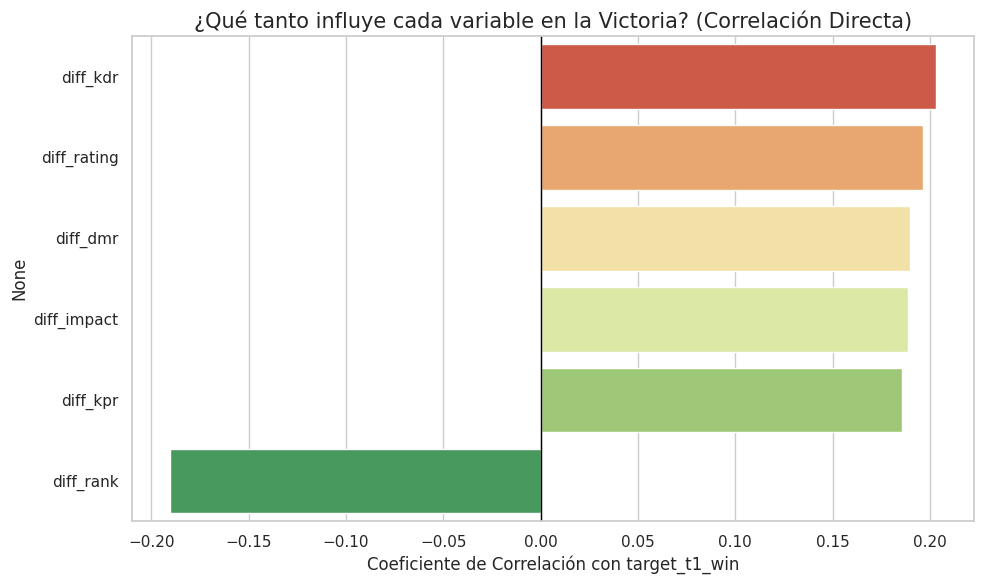

Variables con mayor poder predictivo:
diff_kdr       0.202960
diff_rating    0.196371
diff_dmr       0.189704
diff_impact    0.188695
diff_kpr       0.185758
diff_rank     -0.190337
Name: target_t1_win, dtype: float64


In [2]:
# Seleccionamos las variables diferenciales y el target
diff_cols = [c for c in df.columns if c.startswith('diff_')] + ['target_t1_win']
corr_data = df[diff_cols].corr()

# Gráfica de Barras de Correlación con el Target (ORDENADA)
target_corr = corr_data['target_t1_win'].drop('target_t1_win').sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=target_corr.values, y=target_corr.index, palette='RdYlGn')
plt.title('¿Qué tanto influye cada variable en la Victoria? (Correlación Directa)', fontsize=15)
plt.xlabel('Coeficiente de Correlación con target_t1_win')
plt.axvline(0, color='black', linewidth=1)
plt.tight_layout()
plt.savefig('justificacion_correlacion_barras.png', dpi=300)
plt.show()

print("Variables con mayor poder predictivo:")
print(target_corr)


## 2. Evidencia para Prior 1: Rating (Habilidad)
¿Por qué el Rating es nuestra Prior Informativa? 
Veamos cómo cambia la tasa de victoria según el diferencial de Rating.


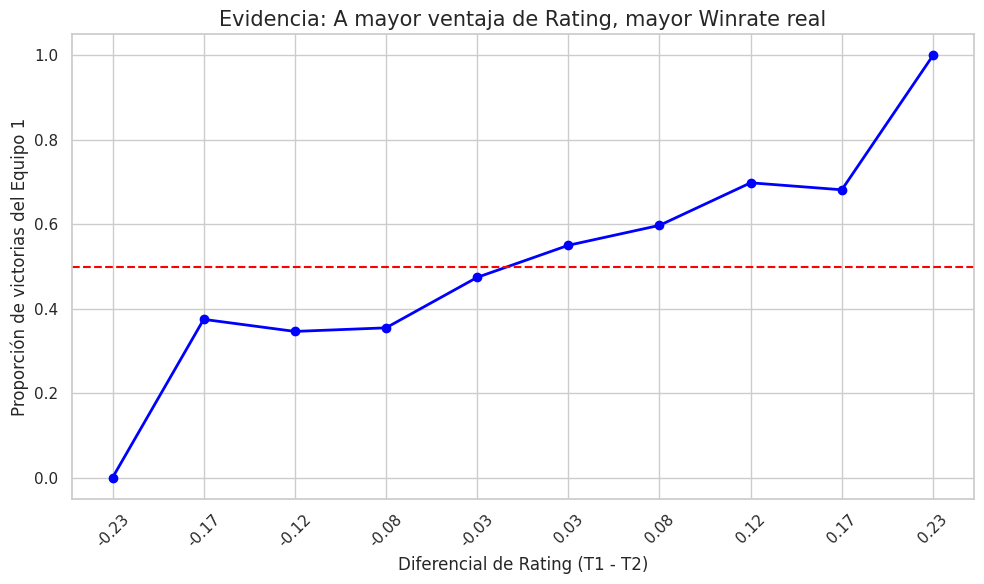

In [3]:
# Agrupamos por bines de rating para ver la tendencia clara
df['rating_bin'] = pd.cut(df['diff_rating'], bins=10)
win_rate_rating = df.groupby('rating_bin')['target_t1_win'].mean()

plt.figure(figsize=(10, 6))
plt.plot(range(len(win_rate_rating)), win_rate_rating.values, marker='o', linewidth=2, color='blue')
plt.xticks(range(len(win_rate_rating)), [f"{i.mid:.2f}" for i in win_rate_rating.index], rotation=45)
plt.axhline(0.5, color='red', linestyle='--')
plt.title('Evidencia: A mayor ventaja de Rating, mayor Winrate real', fontsize=15)
plt.ylabel('Proporción de victorias del Equipo 1')
plt.xlabel('Diferencial de Rating (T1 - T2)')
plt.tight_layout()
plt.savefig('evidencia_rating_winrate.png', dpi=300)
plt.show()


## 3. Evidencia para Prior 2: Impacto (Capacidad Táctica)
¿El impacto realmente separa a los ganadores de los perdedores?
Visualizamos la distribución del impacto para partidas ganadas vs partidas perdidas.


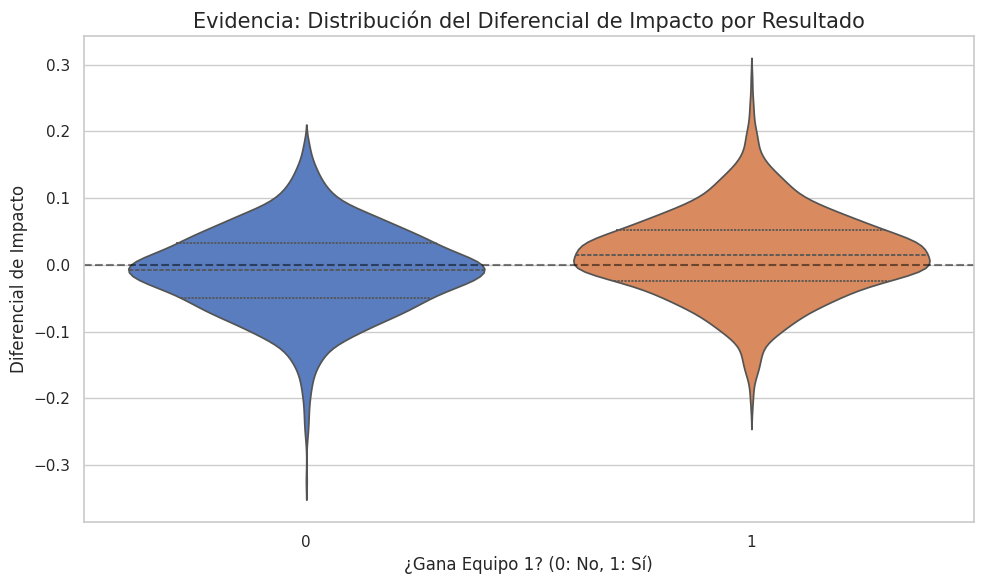

In [4]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='target_t1_win', y='diff_impact', palette='muted', inner="quart")
plt.title('Evidencia: Distribución del Diferencial de Impacto por Resultado', fontsize=15)
plt.xlabel('¿Gana Equipo 1? (0: No, 1: Sí)')
plt.ylabel('Diferencial de Impacto')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('evidencia_impacto_violin.png', dpi=300)
plt.show()


## 4. Evidencia para Prior 3: Mapa y Bando
Analizamos si existe una ventaja por mapa en términos de rondas ganadas.


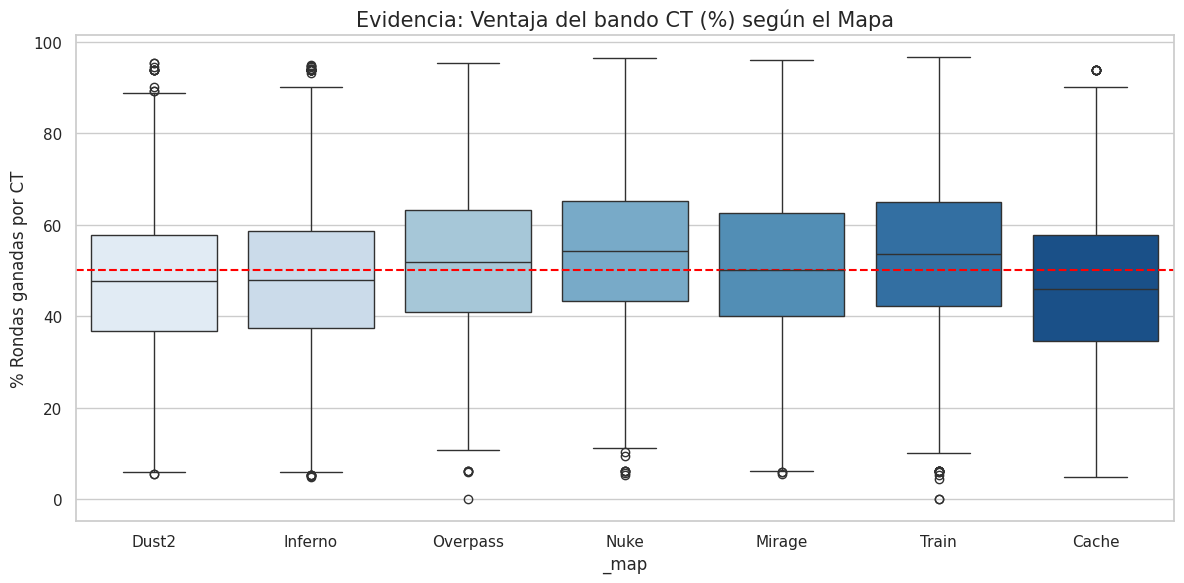

In [5]:
# Usando results.csv para mayor detalle
df_res = pd.read_csv('../../../data/raw/results.csv')
df_res['total_r'] = df_res['result_1'] + df_res['result_2']
df_res['ct_winrate'] = ((df_res['ct_1'] + df_res['ct_2']) / df_res['total_r']) * 100

common_maps = df_res['_map'].value_counts().head(7).index
df_map_bias = df_res[df_res['_map'].isin(common_maps)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_map_bias, x='_map', y='ct_winrate', palette='Blues')
plt.axhline(50, color='red', linestyle='--')
plt.title('Evidencia: Ventaja del bando CT (%) según el Mapa', fontsize=15)
plt.ylabel('% Rondas ganadas por CT')
plt.tight_layout()
plt.savefig('evidencia_mapa_bias.png', dpi=300)
plt.show()
